In [1]:
import pandas as pd
import numpy as np

### creating the Journalism paragraph data
this data is all the paragraph data from the NYT metadata. It is unprocessed and still needs to be made into a format for NLP

In [2]:
journals_raw_3 = pd.read_csv('articles1.csv', usecols=['content'])
journals_raw_2 = pd.read_csv('Articles.csv', encoding='cp1252').dropna()
def remove_comma(text):
    if ":" in text:
        text=text.split(':')[1]
        return text

journals_raw_1 = pd.read_csv('bbc_news_list_uk.csv', usecols=['content']).dropna()
journals_raw_2['Article']= journals_raw_2['Article'].apply(remove_comma)

#creating a combined dataset that has many items
journals = pd.concat([journals_raw_2['Article'], journals_raw_1["content"], journals_raw_3["content"]]).copy(deep=True)
print(journals.shape)
print(journals.head())
journals.to_csv('journals.csv')
#text hodls the data in this

(68160,)
0     The Sindh government has decided to bring dow...
1     Asian markets started 2015 on an upswing in l...
2      Hong Kong shares opened 0.66 percent lower M...
3     Asian markets tumbled Tuesday following painf...
4     US oil prices Monday slipped below $50 a barr...
dtype: object


### creating the scientific documents data
this has a dataset of papers that we need to break into chunks of text. we will need to make sure that no titles or anything is in this. 
we need to make a sentence length for each item so that we can do this. this will be found later when all data is loaded. currently 1000 papers which will be a lot more in sentences.

In [2]:
from datasets import load_dataset
dataset = load_dataset('scientific_papers', 'arxiv',trust_remote_code=True, split='train')
print(dataset.head())
scientific_raw = pd.read_csv('scisumm.csv', usecols=['text']).dropna()
print(scientific_raw.shape)



/Users/curranmaguire/opt/anaconda3/envs/pytorch_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
import re

def remove_latex_markup(text):
    # Remove inline math wrapped in $...$
    text = re.sub(r'\$.*?\$', '', text)
    
    # Remove display math wrapped in \[...\]
    text = re.sub(r'\\\[.*?\\\]', '', text)
    
    # Remove simple LaTeX commands like \command{arg}
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    
    # Remove custom @xmath and @xcite commands from the provided example
    text = re.sub(r'@\w+', '', text)
    
    # Remove remaining braces after previous replacements
    text = re.sub(r'[\{\}\[\]]', '', text)
    
    return text




### creating the blog posts data


In [4]:
blogs_raw = pd.read_csv('blogtext.csv', usecols=['text']).dropna()
print(blogs_raw.shape)
print(blogs_raw.head())

(681284, 1)
                                                text
0             Info has been found (+/- 100 pages,...
1             These are the team members:   Drewe...
2             In het kader van kernfusie op aarde...
3                   testing!!!  testing!!!          
4               Thanks to Yahoo!'s Toolbar I can ...


### creating the Stories data


In [5]:
stories = pd.read_csv('Stories_Raw.csv', usecols=['text'])
print(stories.shape)

(2119719, 1)


### dataset has been created now to start looking into the data and preprocessing

## start of preprocessing
problem at hand we have four style of data that has varying lengths and sentences. 
- need to make sure sentences are similar length.
- need to make sure the datasets are roughly equal?
- apply NLP preprocessing to these datasets




### Looking at the data

Statistics of sentence lengths for Journal Data (Sample):
Journal Data shape: (68160,)
count    10000.000000
mean       569.016800
std        586.149706
min          1.000000
25%        226.000000
50%        406.000000
75%        736.000000
max      13921.000000
dtype: float64
Statistics of sentence lengths for Blogs (Sample):
Blogs shape: (681284,)
count    10000.000000
mean       234.251400
std        403.630832
min          6.000000
25%         62.000000
50%        139.000000
75%        296.000000
max      25452.000000
Name: text, dtype: float64
Statistics of sentence lengths for Scientific (Sample):
Scientific shape: (1009,)
count    10000.000000
mean      4669.464900
std       2822.812641
min          6.000000
25%       3400.250000
50%       4040.000000
75%       4837.000000
max      23625.000000
Name: text, dtype: float64
Statistics of sentence lengths for Stories (Sample):
Stories shape: (2119719,)
count    10000.000000
mean       171.322700
std         75.879512
min          1.

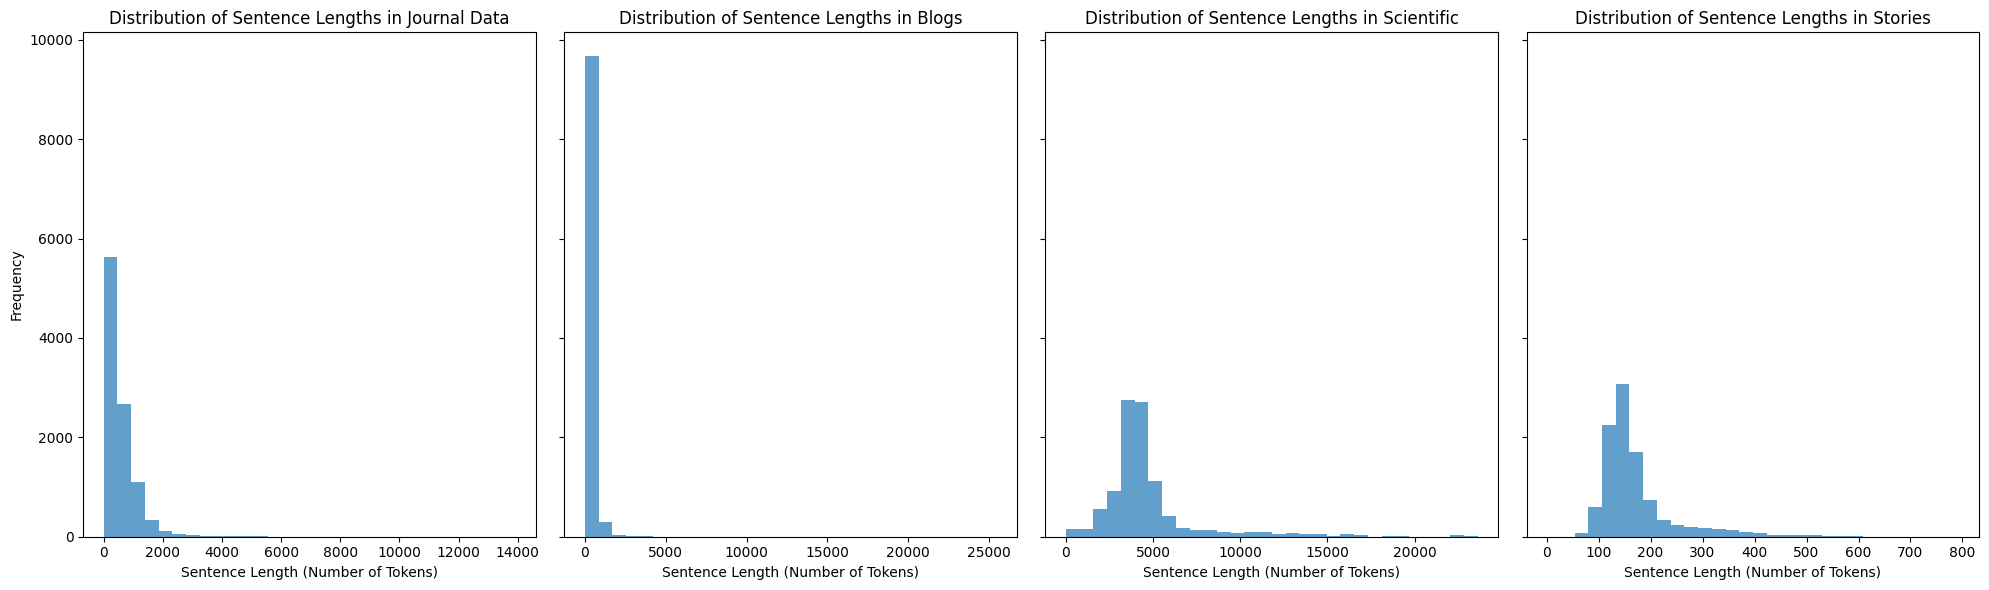

In [7]:
import matplotlib.pyplot as plt

# Assuming journal_data, blogs, stories are your datasets
datasets = [journals, blogs_raw['text'], scientific_raw['text'], stories['text']]
dataset_names = ['Journal Data', 'Blogs', 'Scientific', 'Stories']

# Create a figure for subplots
fig, axs = plt.subplots(nrows=1, ncols=len(datasets), figsize=(20, 6), sharey=True)

for i, df in enumerate(datasets):
    # Vectorized operation for token length calculation

    df = df.apply(lambda x: str(x))
    lengths = df.sample(10000, replace=True).str.split(' ').apply(len)

    
    # Calculate and print statistics
    print(f"Statistics of sentence lengths for {dataset_names[i]} (Sample):")
    print(f'{dataset_names[i]} shape: {df.shape}')
    print(lengths.describe())

    # Plotting the histogram on a subplot
    axs[i].hist(lengths, bins=30, alpha=0.7)  # Reduced number of bins
    axs[i].set_title(f'Distribution of Sentence Lengths in {dataset_names[i]}')
    axs[i].set_xlabel('Sentence Length (Number of Tokens)')

axs[0].set_ylabel('Frequency')
# Adjust layout to
plt.tight_layout()
plt.show()

### training a tokenizer on the dataset


In [8]:
from tokenizers.pre_tokenizers import Whitespace
from transformers import AutoTokenizer
from tokenizers import Tokenizer
from tokenizers.models import BPE
import os
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
files = [f"{split}.csv" for split in ["scisumm", "Stories_Raw", "journals", "blogtext"]]
from tokenizers.trainers import BpeTrainer
trainer = BpeTrainer(special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])
tokenizer.train(files, trainer)
tokenizer.save(os.getcwd() + "/tokenizer-BPE-1.json")


/Users/curranmaguire/opt/anaconda3/envs/pytorch_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:

def split_data(text:'list[str]')->'list[str]':
    #use a sentence splitter from NLTK and split the items into these sentences
    #add a sentence in the dataset until it's length is >80
    #add this to a new dataframe
    list_of_sentences = []
    if len(text) < 90:
        list_of_sentences.append(text)

        return list_of_sentences
    i=0
    new_sentence = []
    while i < len(text):
        if len(new_sentence) < 90:
            new_sentence.append(text[i])
            i+=1 
        else:
            list_of_sentences.append(new_sentence)
            new_sentence = []

    return list_of_sentences



def preprocess(text:str)->'list[str]':

    tokens = tokenizer.encode(str(text))
    final_array= split_data(tokens.ids)
    return final_array
    # lower case the data
    # split the data to make multiple input items for long paragraphs
    # tokenize the data


In [10]:

import matplotlib.pyplot as plt

# Assuming journal_data, blogs, stories are your datasets
datasets = [journals, blogs_raw['text'], scientific_raw['text'], stories['text']]
dataset_names = ['Journal Data', 'Blogs', 'Scientific', 'Stories']

# Create a figure for subplots
fig, axs = plt.subplots(nrows=1, ncols=len(datasets), figsize=(20, 6), sharey=True)
newdf = pd.DataFrame()
for i, df in enumerate(datasets):
    # Vectorized operation for token length calculation
    df.dropna(inplace=True)
    df = df.apply(preprocess).explode().reset_index(drop=True).dropna()
    newdf[dataset_names[i]] = df
    print(df.dtypes)
    df = df.apply(lambda x: str(x))

    lengths = df.sample(10000).str.split(' ').apply(len)

    
    # Calculate and print statistics
    print(f"Statistics of sentence lengths for {dataset_names[i]} (Sample):")
    print(f'{dataset_names[i]} shape: {df.shape}')
    print(lengths.describe())

    # Plotting the histogram on a subplot
    axs[i].hist(lengths, bins=30, alpha=0.7)  # Reduced number of bins
    axs[i].set_title(f'Distribution of Sentence Lengths in {dataset_names[i]}')
    axs[i].set_xlabel('Sentence Length (Number of Tokens)')

axs[0].set_ylabel('Frequency')
# Adjust layout to
plt.tight_layout()
plt.show()

object
Statistics of sentence lengths for Journal Data (Sample):
Journal Data shape: (507825,)
count    10000.00000
mean        89.85770
std          2.86752
min          1.00000
25%         90.00000
50%         90.00000
75%         90.00000
max         90.00000
dtype: float64
object
Statistics of sentence lengths for Blogs (Sample):
Blogs shape: (1956023,)
count    10000.000000
mean        83.589000
std         19.232667
min          1.000000
25%         90.000000
50%         90.000000
75%         90.000000
max         90.000000
Name: text, dtype: float64
object
Statistics of sentence lengths for Scientific (Sample):
Scientific shape: (71996,)
count    10000.0
mean        90.0
std          0.0
min         90.0
25%         90.0
50%         90.0
75%         90.0
max         90.0
Name: text, dtype: float64


### Post processing

I now have tokenized datasets in the newDF list. I then need to potentially do more procesing to the data.

I can also look at training a Bert classifier for this data. I will need to now transfer this to NCC

to do this I will need to create a dataset that has all the data in and that uses a labelling method to label the data as each potential datapoint. This will be easy as I just need to add a target data item to each dataframe



In [ ]:
temp = []
target = []
for i, dataset in enumerate(newdf.columns):
    temp = pd.concat([temp, newdf[dataset]])
    target = pd.concat([target, np.array([i]*len(newdf[dataset]))])
final_data = pd.DataFrame({'input':temp, 'target':target})
print(final_data.head())

